# Pipeline 2 — ordem inversa

Etapas:

1. Ruído gaussiano (sigma 15, semente 42)
2. High-boost (k 1,5)
3. Filtro Gaussiano 5x5 (sigma 1)
4. Equalização de histograma

Mesmas técnicas da pipeline 1, na ordem inversa depois do ruído. Só a ordem muda.

In [ ]:
import os
import subprocess
import sys

if "google.colab" in sys.modules:
    PASTA_REPO = "/content/trabalho-pdi-m1.2"
    if not os.path.isdir(PASTA_REPO):
        subprocess.run(["git", "clone", "https://github.com/mello745/trabalho-pdi-m1.2.git", PASTA_REPO], check=True)
    os.chdir(os.path.join(PASTA_REPO, "notebooks"))

In [1]:
import sys
sys.path.insert(0, "../src")

from pdi import pipeline
from pdi.gustavo import io_utils
from pdi.gustavo import operacoes_pontuais as op
from pdi.heloisa import ruido, suavizacao
from pdi.joao import agucamento, metricas

IMAGENS = {
    "ISIC_0014049": "../data/originais/ISIC_0014049.jpg",  # baixo contraste
    "ISIC_7236365": "../data/originais/ISIC_7236365.jpg",  # pelos densos
    "ISIC_0021531": "../data/originais/ISIC_0021531.jpg",  # bordas difusas
}

CONFIG_2 = [
    ("degradada",  lambda im: ruido.ruido_gaussiano(im, sigma=15, semente=42)),
    ("agucada",    lambda im: agucamento.high_boost(im, tamanho=3, sigma=1.0, k=1.5)),
    ("suavizada",  lambda im: suavizacao.filtro_gaussiano(im, tamanho=5, sigma=1.0)),
    ("equalizada", lambda im: op.equalizar_histograma(im)),
]

CONFIG = CONFIG_2

## 1. Execução nas 3 imagens

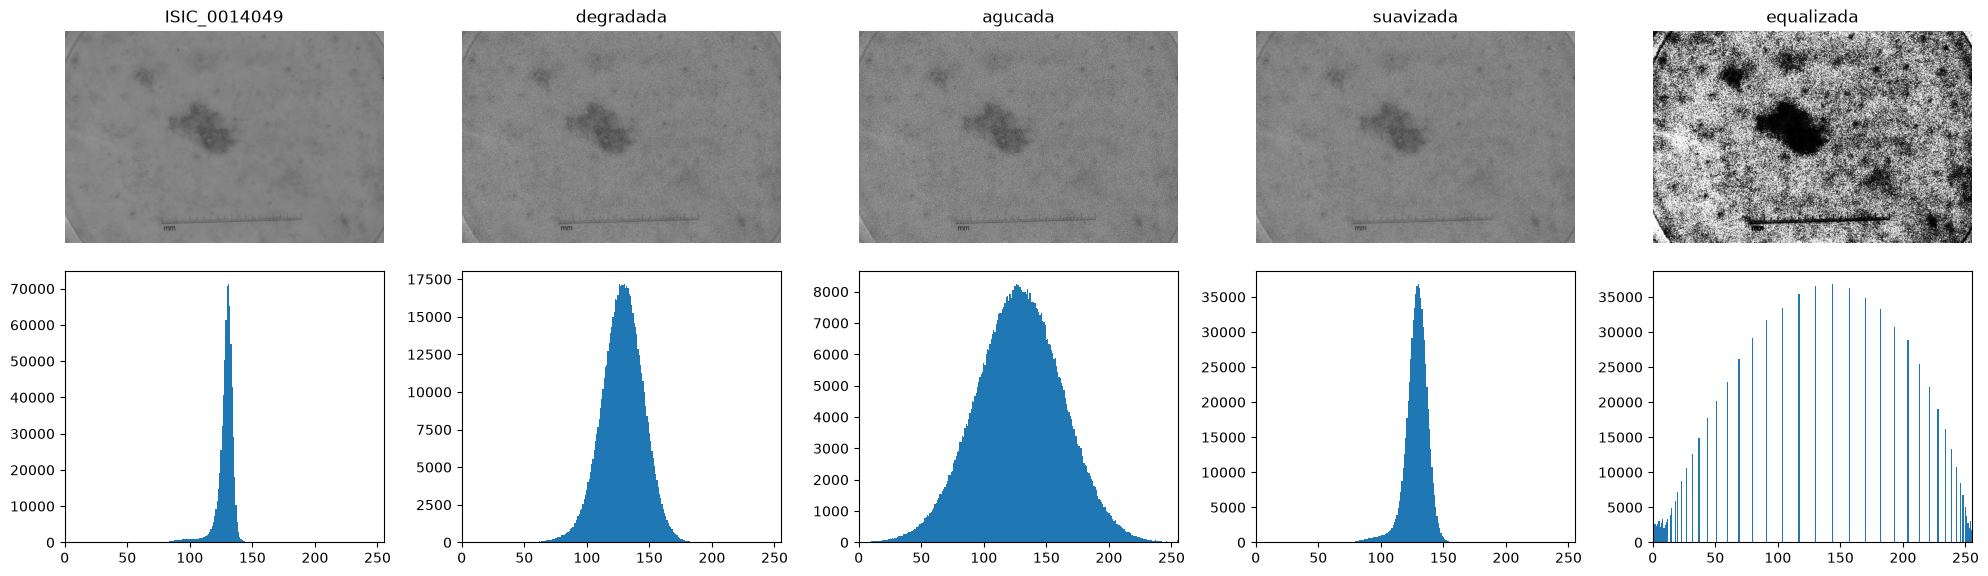

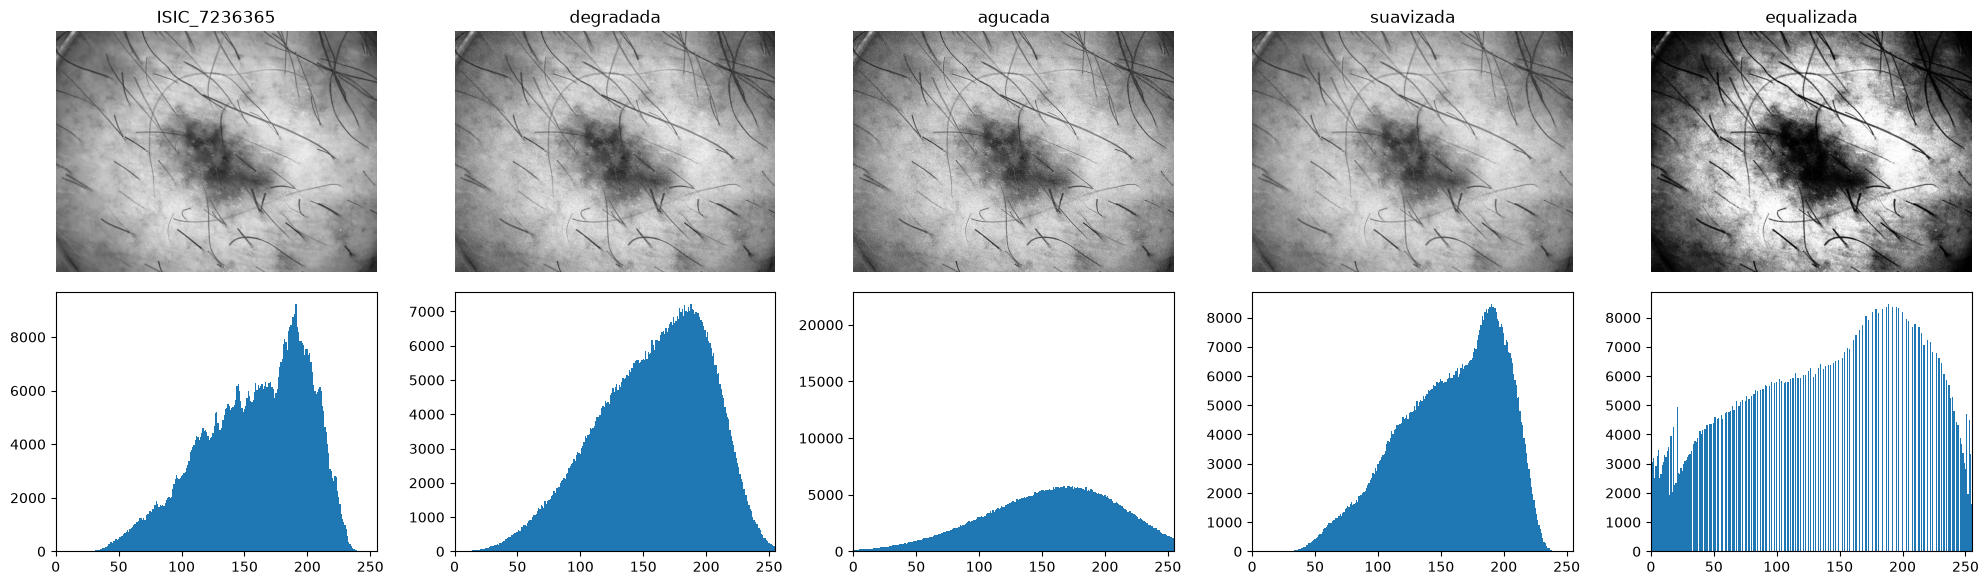

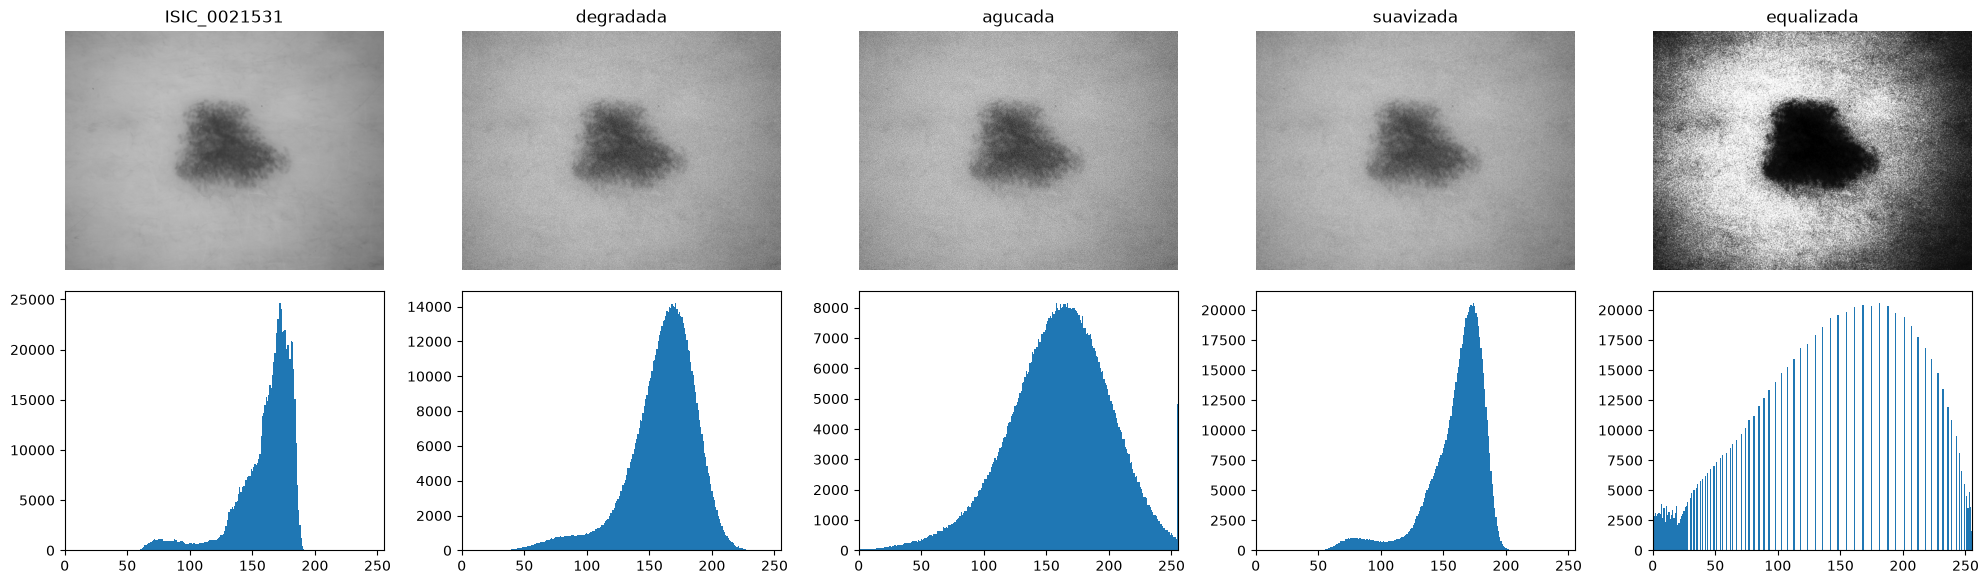

In [2]:
resultados = {}
for nome, caminho in IMAGENS.items():
    img = io_utils.carregar_cinza(caminho, largura_max=1024)
    resultados[nome] = pipeline.executar(img, CONFIG)
    io_utils.mostrar(pipeline.imagens(resultados[nome]),
                     [nome if e == "original" else e for e in pipeline.nomes(resultados[nome])])

## 2. Métricas (referência: original sem ruído)

In [3]:
for nome, res in resultados.items():
    original = res[0][1]
    print(nome)
    for etapa, im in res[1:]:
        print(f"  {etapa:<11} PSNR {metricas.psnr(original, im):6.2f} dB   SSIM {metricas.ssim(original, im):.3f}")

ISIC_0014049


  degradada   PSNR  24.60 dB   SSIM 0.240


  agucada     PSNR  17.61 dB   SSIM 0.063


  suavizada   PSNR  32.55 dB   SSIM 0.679


  equalizada  PSNR  11.22 dB   SSIM 0.038
ISIC_7236365


...

  equalizada  PSNR  14.85 dB   SSIM 0.473
ISIC_0021531


  degradada   PSNR  24.60 dB   SSIM 0.232


  agucada     PSNR  17.66 dB   SSIM 0.059


  suavizada   PSNR  32.64 dB   SSIM 0.677


  equalizada  PSNR  11.98 dB   SSIM 0.113


## 3. Observações

Notebook demonstrativo: mostra cada estágio da pipeline 2 nas três imagens e as métricas de cada estágio.
A comparação com a pipeline 1 e a discussão dos resultados estão em [trabalho_m1.ipynb](trabalho_m1.ipynb).

## 4. Teste com imagem nova

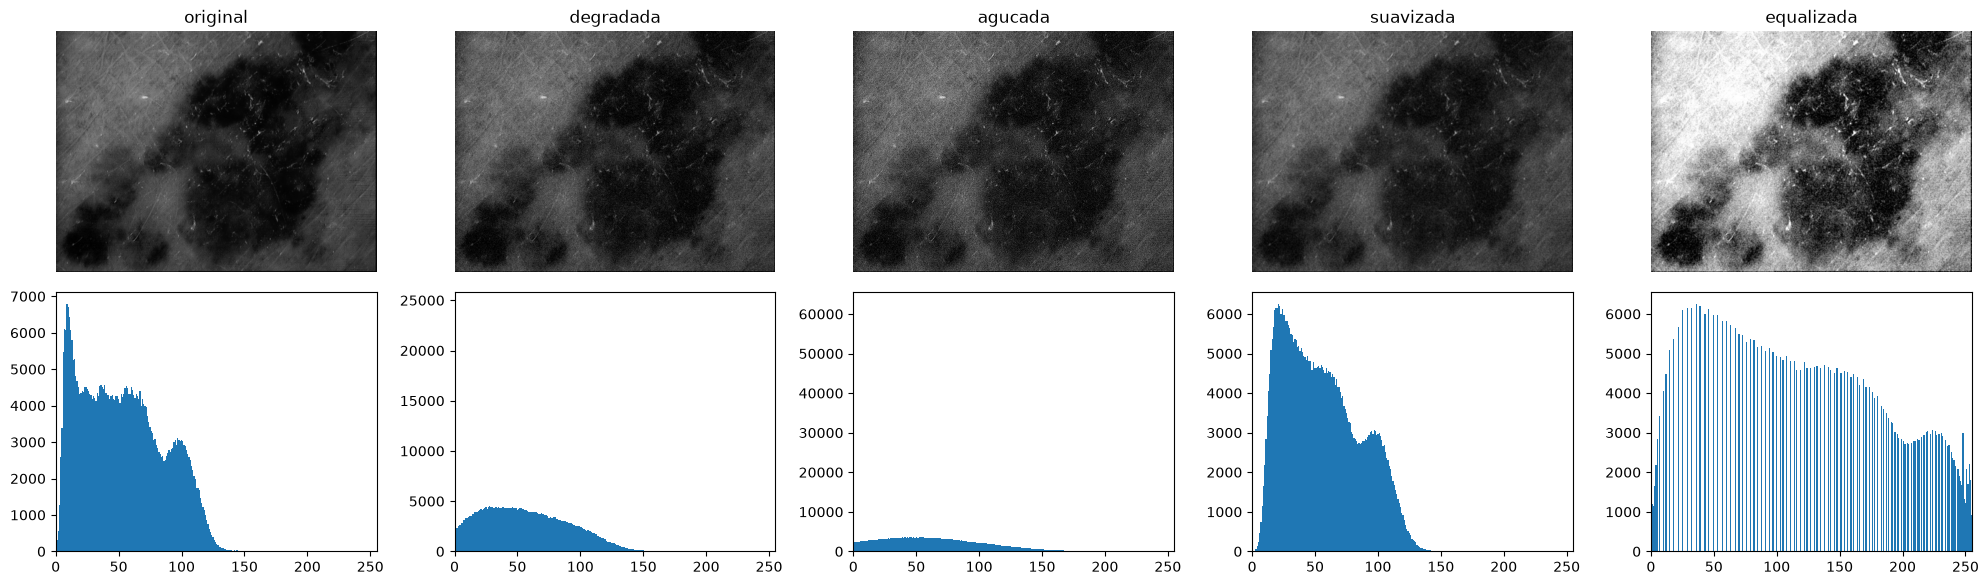

degradada   PSNR  24.94 dB   SSIM 0.397


agucada     PSNR  18.47 dB   SSIM 0.164


suavizada   PSNR  30.89 dB   SSIM 0.739


equalizada  PSNR   9.37 dB   SSIM 0.339


In [4]:
IMAGEM_TESTE = "../data/originais/ISIC_0112420.jpg"  # troque por qualquer imagem

img = io_utils.carregar_cinza(IMAGEM_TESTE, largura_max=1024)
res = pipeline.executar(img, CONFIG)
io_utils.mostrar(pipeline.imagens(res), pipeline.nomes(res))
for etapa, im in res[1:]:
    print(f"{etapa:<11} PSNR {metricas.psnr(img, im):6.2f} dB   SSIM {metricas.ssim(img, im):.3f}")